Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


Epoch 1/15 - Loss: 0.6036 - Val Acc: 0.8666
Epoch 2/15 - Loss: 0.3105 - Val Acc: 0.8968
Epoch 3/15 - Loss: 0.2339 - Val Acc: 0.9028
Epoch 4/15 - Loss: 0.2075 - Val Acc: 0.9043
Epoch 5/15 - Loss: 0.1744 - Val Acc: 0.9067
Epoch 6/15 - Loss: 0.1488 - Val Acc: 0.9013
Epoch 7/15 - Loss: 0.1356 - Val Acc: 0.9062
Epoch 8/15 - Loss: 0.1213 - Val Acc: 0.9058
Epoch 9/15 - Loss: 0.1006 - Val Acc: 0.9028
Epoch 10/15 - Loss: 0.0942 - Val Acc: 0.9172
Epoch 11/15 - Loss: 0.0755 - Val Acc: 0.9147
Epoch 12/15 - Loss: 0.0772 - Val Acc: 0.9152
Epoch 13/15 - Loss: 0.0764 - Val Acc: 0.9082
Epoch 14/15 - Loss: 0.0621 - Val Acc: 0.9182
Epoch 15/15 - Loss: 0.0533 - Val Acc: 0.9157
Best Val Acc: 0.9181547619047619
Test Accuracy: 0.9180246913580247

Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.86      0.79      0.83       403
Corona Virus Disease       1.00      0.99      0.99       407
              Normal       0.96      0.97      0.96     

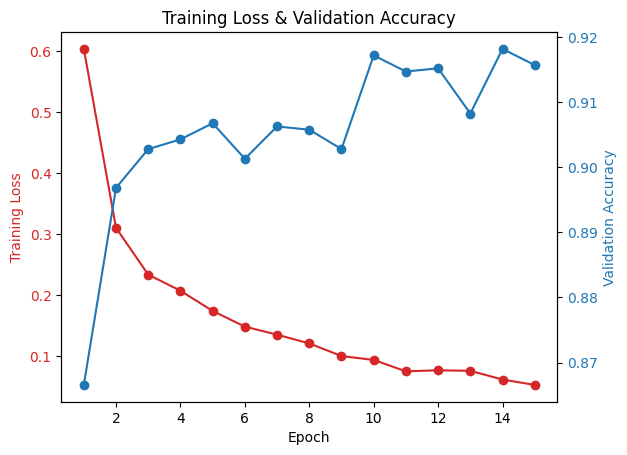

In [5]:

# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import os
from PIL import Image
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import math
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt










# Mounting G-Drive
from google.colab import drive
drive.mount('/content/drive')


# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Paths for Dataset

data_dir = '/content/drive/My Drive/Lung Disease Dataset'
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"

# Lung Disease Classification with EfficientNet-B0 (Simplified)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np


img_size = 224
batch_size = 32


# 1. Data transforms
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
# 2. Dataset & Dataloaders (Update paths as needed)
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)


class_names = train_data.classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Model
model = models.efficientnet_b0(pretrained=True)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(in_features, len(class_names))
)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4. Training Loop
epochs = 15
best_val_acc = 0.0
train_losses, val_accuracies = [], []

for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

print("Best Val Acc:", best_val_acc)



Test Accuracy: 0.9180246913580247

Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.86      0.79      0.83       403
Corona Virus Disease       1.00      0.99      0.99       407
              Normal       0.96      0.97      0.96       404
        Tuberculosis       0.99      1.00      1.00       408
     Viral Pneumonia       0.78      0.84      0.81       403

            accuracy                           0.92      2025
           macro avg       0.92      0.92      0.92      2025
        weighted avg       0.92      0.92      0.92      2025



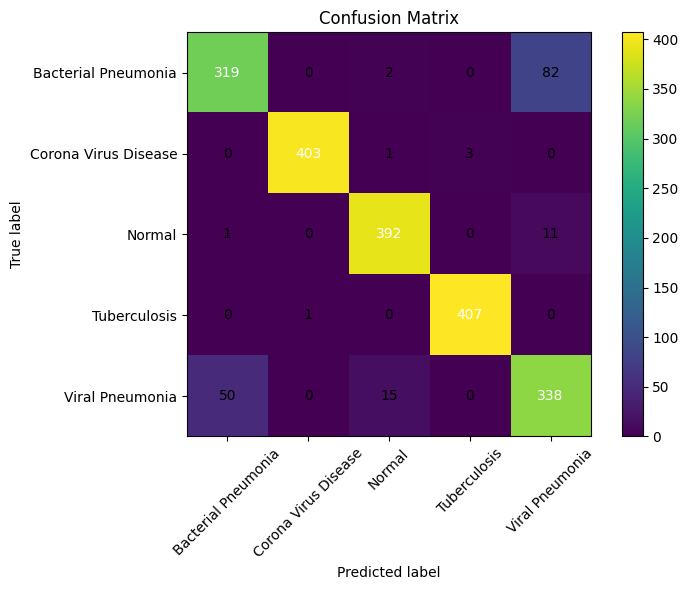

Macro ROC-AUC (OvR): 0.9885482285319354


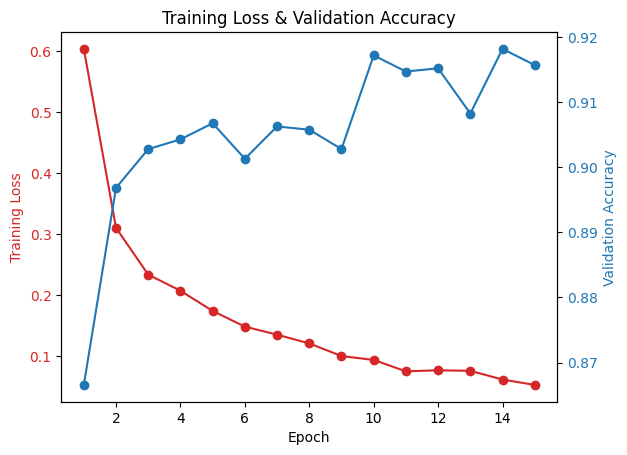

In [8]:
# 5. Evaluation on Test Set
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
test_labels, test_preds, test_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

print("Test Accuracy:", (test_preds == test_labels).mean())
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.tight_layout()
plt.show()

# ROC-AUC (OvR)
y_true_ovr = np.eye(len(class_names))[test_labels]
macro_auc = roc_auc_score(y_true_ovr, np.array(test_probs), average='macro', multi_class='ovr')
print("Macro ROC-AUC (OvR):", macro_auc)

# 6. Plot Loss & Val Accuracy
epochs_range = range(1, len(train_losses)+1)
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs_range, train_losses, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs_range, val_accuracies, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Training Loss & Validation Accuracy')
plt.show()





In [ ]:
import matplotlib.pyplot as plt

def show_misclassified(test_loader, model, class_names, device, n=10):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break
    plt.figure(figsize=(15, 6))
    for i, (img, true, pred) in enumerate(misclassified):
        img = img.numpy().transpose((1,2,0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage:
show_misclassified(test_loader, model, class_names, device, n=10)
